<h1><center>
King Faisal University <br>
College of Computer Sciences and Information Technology <br>
</h1>


<strong>
<center>CS323: Digital Image Processing – Course Project
<br><br>
<center>Section:81
<br><br>
<center> Academic Year 2024-2025, Second Semester 
<center> Date: [Apr. 03, 2022]

<br><br>
</strong>

<h1><center>
Academic Year 2024-2025, Second Semester 
</h1>

# • Challenge 01. Image Enhancement 


# A. Description 


Image enhancement is an essential and important process in digital image. It is used to 
improve the quality of the image to make it more suitable for display or further analysis. 
Images from different sources such as satellite, medical devices, digital cameras, can suffer 
from poor contrast and noise. Therefore, those captured images should be preprocessed 
through different enhancement techniques to be used in more advance tasks.  

# B. Task 

Apply and compare different image processing techniques to enhance the image. 

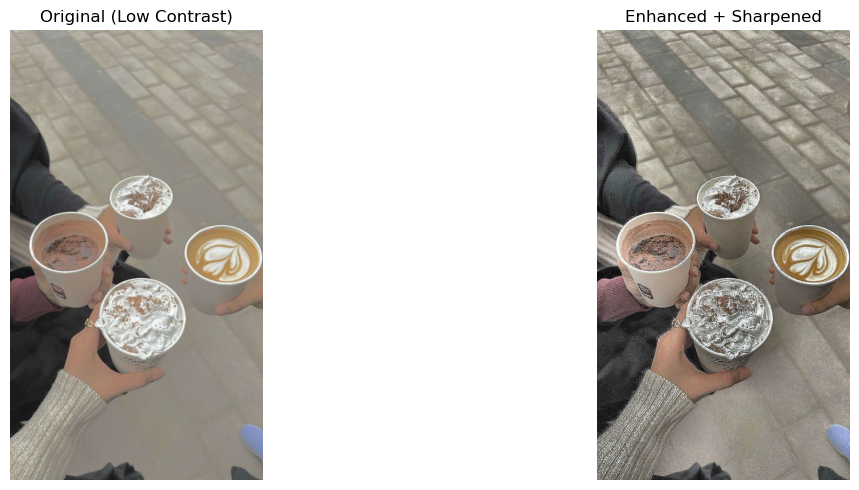

In [17]:
#write code
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to display images
def plot_image(img, title):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')

# Step 1: Load the low contrast image
image = cv2.imread("images/challenge1.jpg")



# Step 2: Convert to LAB color space and apply CLAHE to L channel
# CLAHE = Contrast Limited Adaptive Histogram Equalization
# Convert the original image from BGR to LAB color space
# LAB separates brightness (L) from color information (A and B)
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

# Split LAB image into individual channels: L = Lightness, A = Green–Red, B = Blue–Yellow
l, a, b = cv2.split(lab)

# Create a CLAHE object to enhance contrast locally (clipLimit controls contrast strength)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE only to the Lightness (L) channel to enhance contrast
cl = clahe.apply(l)

# Merge the enhanced L channel with the original A and B channels
lab_enhanced = cv2.merge((cl, a, b))

# Convert the LAB image back to BGR for display and saving
enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)



# Step 3: Apply light sharpening
# Define a sharpening kernel (filter) to enhance edges and make the image appear crisper
# This kernel emphasizes the center pixel while subtracting surrounding pixels
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

# Apply the sharpening kernel using filter2D (convolution operation)
# -1 as depth means it keeps the original image depth
sharpened = cv2.filter2D(enhanced, -1, sharpen_kernel)



# Step 4: Save the final result
cv2.imwrite("enhanced_sharpened.jpg", sharpened)

# Step 5: Show comparison
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plot_image(image, "Original (Low Contrast)")
plt.subplot(1, 2, 2)
plot_image(sharpened, "Enhanced + Sharpened")
plt.tight_layout()
plt.show()

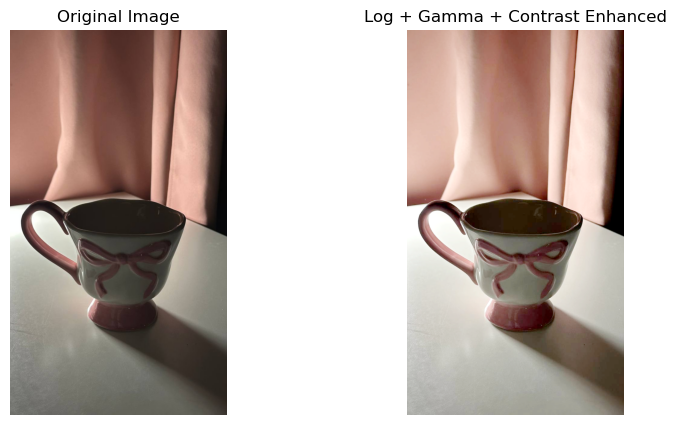

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to display images
def plot_image(img, title):
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Load the image in BGR format and convert to float32
image_path = "images/challenge11.jpg"
image = cv2.imread(image_path).astype(np.float32)


# Step 1: Log Transformation
c = 255 / (np.log(1 + np.max(image)))
log_transformed = c * np.log(1 + image)

# Normalize to [0, 1] before gamma correction
log_normalized = log_transformed / 255.0

# Step 2: Gamma Correction with milder gamma
gamma = 0.95
gamma_corrected = np.power(log_normalized, gamma)

# Step 3: Soft Contrast Stretching (less aggressive)
enhanced = np.clip(gamma_corrected * 255, 0, 255).astype(np.uint8)  # Convert to 8-bit scale
min_val = np.percentile(enhanced, 2)  # Lower bound to suppress dark outliers
max_val = np.percentile(enhanced, 98)  # Upper bound to suppress bright outliers
contrast_adjusted = ((enhanced - min_val) / (max_val - min_val)) * 255  # Stretch contrast
contrast_adjusted = np.clip(contrast_adjusted, 0, 255).astype(np.uint8)  # Final adjustment and conversion

# Convert for plotting
# Reload the original image in uint8 format (for displaying without enhancements)
image_uint8 = cv2.imread(image_path) 
# Convert the original image from BGR to RGB for correct display with matplotlib
image_rgb = cv2.cvtColor(image_uint8, cv2.COLOR_BGR2RGB)
# Convert the enhanced image (after log + gamma + contrast) from BGR to RGB for display
final_rgb = cv2.cvtColor(contrast_adjusted, cv2.COLOR_BGR2RGB)


# Display the images side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plot_image(image_rgb, "Original Image")

plt.subplot(1, 2, 2)
plot_image(final_rgb, "Log + Gamma + Contrast Enhanced")
plt.subplots_adjust(wspace=0.05)
plt.show()


# Explanation of the Image Enhancement Methods Used:

In this enhancement task, we applied a combination of Log Transformation, Power-Law (Gamma) Correction, and Contrast Stretching to improve the lighting and clarity of the image while preserving its soft and warm atmosphere.

1. Log Transformation

Log transformation is used to enhance details in darker areas of the image.
It applies the formula:
    s = c * log(1 + r)
where r is the original pixel value and c is a scaling constant.
This method effectively brightens shadows without overexposing highlights, which is ideal for dim regions like the shadowed part of the cup.

3. Power-Law (Gamma) Correction

This technique adjusts the brightness in a non-linear way using the formula:
    s = r^γ
We used a gamma value of 0.95 to slightly brighten the image while maintaining natural contrast. Gamma < 1 brightens midtones more gently than log transformation alone.

4. Contrast Stretching

To enhance the overall clarity, we applied linear contrast stretching by remapping the pixel intensity range.
Instead of stretching the entire range from minimum to maximum, we used percentiles (2nd and 98th) to avoid extreme pixel values (e.g., strong shadows or highlights), resulting in a soft contrast boost that improves visual quality without losing balance.

 Challenges We Faced:

Color Distortion Due to Improper Format
Initially, when applying transformations to images in BGR or unnormalized formats, the image appeared too purple or discolored. This was caused by applying operations before proper conversion to float32 or RGB. The issue was resolved by converting the image early in the pipeline and handling color spaces properly.

Excessive Brightness
When using a gamma value that was too low (e.g., γ = 0.7) after log transformation, the image became overexposed and lost detail in highlights. Adjusting to γ = 0.95 and using a softer contrast stretch helped restore visual balance.

Mathematical Warnings
Using log() directly on integer pixel values led to:

In [ ]:
RuntimeWarning: divide by zero encountered in log

This happened because pixel values must be floats when passed to functions like log() and power(). We fixed this by explicitly converting the image to float32 before applying any enhancement formula.



# C. Required image 

For this challenge you need to take a photo of any scene. This photo should suffer from poor 
quality such as poor contrast due to the inaccurate light effect or using similar tones for both 
background and foreground. Moreover, you should reduce the noise if it exists in your image. 
You can also use an old photo that has a poor quality.  

# • Challenge 02. Edge Detection

# A. Description 


Edge detection is one of the most fundamental yet powerful techniques in autonomous 
vehicle (AV) perception systems. It helps self-driving cars understand their environment by 
identifying key structural features in images. 

# B. Task 


Explore how basic edge detection techniques can be used for lane detection and obstacle 
avoidance.

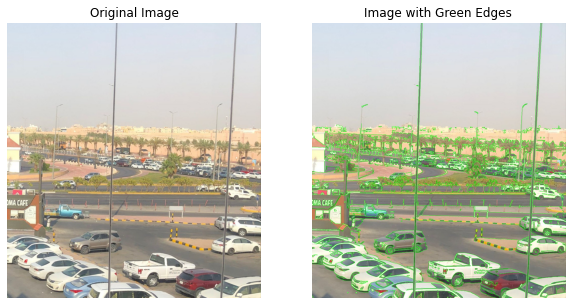

In [1]:
#write code
#write code
# Libraries used in the program:
import cv2  # OpenCV: used for reading, processing, and manipulating images
import matplotlib.pyplot as plt  # For displaying images side by side using plots

# Read the original image (OpenCV reads in BGR format)
img = "images/challenge2.jpg"
image = cv2.imread(img)

# Convert image from BGR to Grayscale
# Why? Edge detection works best on grayscale images because it focuses on intensity changes, not color.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to reduce noise and smooth the image
# Why? Blurring helps remove small variations and sharp noise which may otherwise appear as false edges
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny edge detection to find edges based on intensity gradient
# DIP Technique used: Canny is a multi-stage algorithm to detect strong and weak edges
edges = cv2.Canny(blurred, 50, 150)

# Create a copy of the original image to draw edges on it
image_with_edges = image.copy()

# Paint detected edges in green (where the edge array is not zero)
# This makes edges visually stand out on the original image
image_with_edges[edges != 0] = [0, 255, 0]  # Green in BGR

# Convert images from BGR to RGB before displaying with matplotlib
# Why? OpenCV uses BGR by default, but matplotlib expects RGB format
original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
output = cv2.cvtColor(image_with_edges, cv2.COLOR_BGR2RGB)

# Display the original and processed images side by side
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output)
plt.title("Image with Green Edges")
plt.axis('off')

# Adjust layout to avoid overlap between plots
plt.show()

# Explanation

This Python code uses the Canny edge detection algorithm to identify edges in a road image, a key technique in Digital Image Processing. The image is first converted to grayscale to simplify processing, then smoothed using Gaussian blur to reduce noise. Edges are detected based on intensity changes, and highlighted in green on a copy of the original image for better visualization. Finally, the original and processed images are displayed side by side. This method combines grayscale conversion, blurring, and Canny detection to make edge features like lanes and obstacles clearer. Coloring edges green improved the output’s visual clarity.

# C. Required image 


For this challenge you need to take a photo of a road scene — preferably with clear lane 
markings and surrounding objects (e.g., parked cars, pedestrians, road signs). Process the 
image using different edge detection techniques to extract meaningful visual features. 


# • Challenge 03. Image Segmentation  


# A. Description 


Image segmentation is a fundamental task in computer vision that divides an image into 
meaningful regions or objects. It plays a crucial role in fruit classification by accurately 
separating individual fruits within an image, enabling accurate type identification, ripeness 
assessment, and quality control.

# B. Task 


Apply image segmentation techniques to segment fruits into pickable (ripe) and unpickable 
(unripe or damaged) categories based on their colour characteristics.  

Original image shape: (1280, 720, 3)
Flattened image shape: (921600, 3)


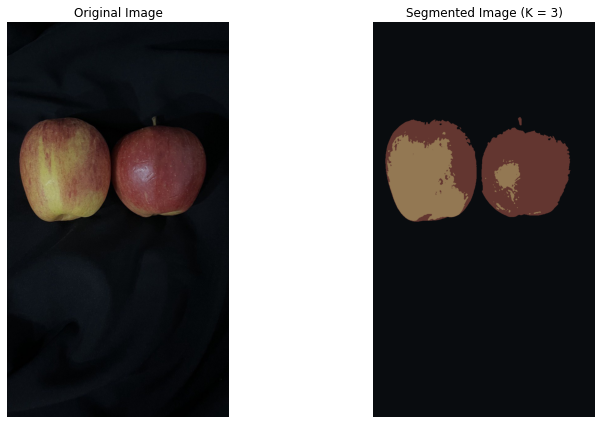

In [1]:
#write code
import cv2          # OpenCV library for computer vision tasks (image processing, filtering)
import numpy as np  # NumPy for numerical operations on image arrays
import matplotlib.pyplot as plt  # Matplotlib for image visualization
#cv2.imread() reads images in BGR format by default 
original_image = cv2.imread('images/challange3.jpg')


# Convert image from default  BGR to RGB color space because  Matplotlib uses RGB format for display
image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
print("Original image shape: {}".format(str(image.shape)))

# Apply median filtering to reduce noise
# Why median filter? Excellent at removing salt-and-pepper noise where photo have this problem
median_filtered = cv2.medianBlur(image, 5)


# Reshape the 3D image array (height × width × channels) into 2D array of pixels
# -1 in reshape means numpy calculates this dimension automatically
vectorized = median_filtered.reshape((-1, 3))
print("Flattened image shape: {}".format(str(vectorized.shape)))

# Convert pixel values to float32 data type because cv2.kmeans() requires float32 input for numerical precision
vectorized = np.float32(vectorized)

# Set clustering termination criteria:
# - cv2.TERM_CRITERIA_EPS: stop when accuracy (epsilon) is reached
# - cv2.TERM_CRITERIA_MAX_ITER: stop after maximum iterations
# - 10: maximum number of iterations
# - 1.0: minimum accuracy required
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

K = 3# Number of clusters 
attempts = 10  # Number of times to run the algorithm from scratch

# Perform K-means clustering:
# - vectorized: input pixel data
# - K: number of clusters
# - None: no initial cluster centers provided
# - criteria: termination conditions
# - attempts: number of executions with different initializations
# - cv2.KMEANS_PP_CENTERS: uses k-means++ for smart center initialization
ret, label, center = cv2.kmeans(vectorized, K, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

# Convert cluster centers back to 8-bit unsigned integer (0-255 range)
center = np.uint8(center)

# Create segmented image by mapping each pixel to its cluster center
result_image = center[label.flatten()].reshape((image.shape))

# Create figure with two subplots (1 row, 2 columns)
plt.figure(figsize=(12, 6))

# Original image subplot
plt.subplot(121)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')  # Hide axes for cleaner display

# Segmented image subplot
plt.subplot(122)
plt.imshow(result_image)
plt.title('Segmented Image (K = {})'.format(K))
plt.axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the figure
plt.show()

# Explanation

This implementation employs key Digital Image Processing (DIP) techniques for robust image segmentation. The pipeline begins with color space conversion from OpenCV's default BGR to RGB format for proper Matplotlib visualization. The core segmentation uses K-means clustering (*K=3*) in RGB space with k-means++ initialization (10 attempts) for optimal color grouping.  

Two additional methods enhance the process:  
1. medianBlur (5×5 kernel): Preprocesses images to remove salt-and-pepper noise for cleaner clustering input  
2. tight_layout: Automatically optimizes subplot spacing in the final visualization for clear comparison of original vs segmented results

The main challenge was selecting the optimal enhancement filter, which was resolved by choosing medianBlur for its superior noise removal capabilities compared to Gaussian and others ‎<This message was edited>

# C. Required image 


Take a clear photo of any type of fruit placed on a plain background. Ensure the image 
includes fruits at different ripeness levels (e.g., red, green, white, or damaged). 

# • Challenge 04. Application of Digital Image processing.  


# A. Description 


Given with different digital image processing topics below, select one of these topics and 
provide an example implementation of this topic using digital image processing technique. 
1. Image enhancement and restoration.  
2. Edge Detection 
3. Image Segmentation 
4. Feature Extraction 
For this challenge you need to give a real-world scenario where the chosen topic can be 
applied on.

# Scenario: 


# Edge Detection Using Canny – Dental X-ray Analysis

In dental clinics, dentists frequently use X-ray images to diagnose tooth damage, root canal treatments, and implant placement. However, raw X-ray images are often difficult to interpret due to low contrast and noise. Edge detection using the Canny algorithm helps enhance these images by clearly outlining tooth structures, roots, and dental implants, making diagnosis more accurate and faster.

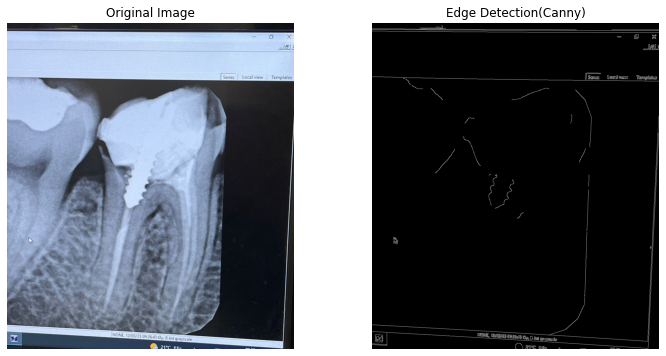

In [4]:
#Import libraries
#A library for using functions that process images
import cv2
#Library for using mathematical functions
from matplotlib import pyplot as plt

# Read the satellite image of the King Faisal University area
#To read the image,library CV2 was used,and a function was used to read the image imread. This function accepts the path to the image
img = cv2.imread("images/challenge.jpg")

# If we upload the image and give a program a command to read it, it will be a picture as it is, and this makes it difficult for the device to understand it and perform operations on it

# Convert image to grayscale
# This simplifies the image by reducing the 3 RGB channels to a single channel
# It makes it easier to process the image computationally
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
#I had a problem  in the result when I used only Canny. The image had a lot of details that overlapped with the important details, so I used blur to remove the unimportant elements
# We used blur to reduce noise before we defined the edges of the image and this gave me better results for the image
blurred_img = cv2.GaussianBlur(gray_img, (5, 5), 0)

#Apply Canny Edge Detection
# We applied Canny edge detection to the blurred grayscale image, using thresholds of 100 and 200 to identify strong edges and suppress weak ones
edges_img = cv2.Canny(blurred_img, 100, 200)

#Display original vs edge-detected images
plt.figure(figsize=(12, 6))
#We used this function to divide the page into two parts, right and left, to display the original image and the modified image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_img, cmap='gray')
plt.title('Edge Detection(Canny)')
plt.axis('off')

plt.show()

# Explanation

The libraries used in this implementation include cv2 for image processing, numpy for numerical operations, and matplotlib.pyplot for displaying images. No custom functions were defined, as the entire process was implemented directly for simplicity. The image was first converted from BGR to grayscale because the Canny edge detection algorithm operates on single-channel images. A Gaussian Blur was then applied to reduce noise and enhance the accuracy of edge detection. The main algorithm used is Canny Edge Detection, which involves several steps: noise reduction, gradient calculation, non-maximum suppression, double thresholding, and edge tracking by hysteresis. During implementation, one of the main challenges was tuning the threshold values. After testing various ranges, the values 50 and 150 were found to produce the most accurate and clear edge outlines, particularly for identifying tooth structures and the dental implant.



# scenario:

In this challenge, we used the Canny Edge Detection algorithm to analyze satellite images of the King Faisal University area to detect uncontrolled urban sprawl. The original images contain a lot of detail, making it difficult to distinguish buildings and roads. After converting the image to grayscale and applying Gaussian Blur, we used Canny to extract only the edges, clearly revealing the boundaries of buildings and roads. This simplification helps entities like the Al-Ahsa Municipality compare images over time to quickly and easily detect any urban changes, without the need for field monitoring.

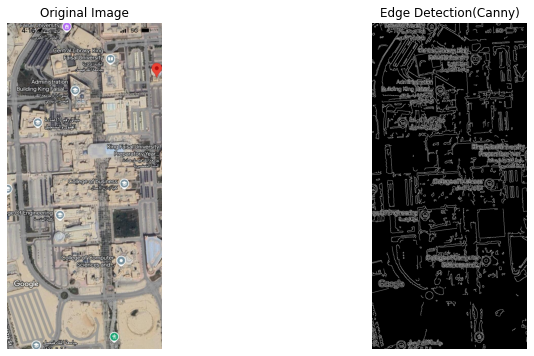

In [11]:
#Import libraries
#A library for using functions that process images
import cv2
#Library for using mathematical functions
from matplotlib import pyplot as plt

# Read the satellite image of the King Faisal University area
#To read the image,library CV2 was used,and a function was used to read the image imread. This function accepts the path to the image
img = cv2.imread("images/challenge4.png")

# If we upload the image and give a program a command to read it, it will be a picture as it is, and this makes it difficult for the device to understand it and perform operations on it

# Convert image to grayscale
# This simplifies the image by reducing the 3 RGB channels to a single channel
# It makes it easier to process the image computationally
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
#I had a problem  in the result when I used only Canny. The image had a lot of details that overlapped with the important details, so I used blur to remove the unimportant elements
# We used blur to reduce noise before we defined the edges of the image and this gave me better results for the image
blurred_img = cv2.GaussianBlur(gray_img, (5, 5), 0)

#Apply Canny Edge Detection
# We applied Canny edge detection to the blurred grayscale image, using thresholds of 100 and 200 to identify strong edges and suppress weak ones
edges_img = cv2.Canny(blurred_img, 100, 200)

#Display original vs edge-detected images
plt.figure(figsize=(12, 6))
#We used this function to divide the page into two parts, right and left, to display the original image and the modified image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_img, cmap='gray')
plt.title('Edge Detection(Canny)')
plt.axis('off')

plt.show()